# Comparing XGBoost and PyTorch Neural Networks on Tabular Data

Machine learning discussions today are heavily dominated by deep learning. Neural networks, transformers, and large-scale AI systems often receive most of the attention, leading many beginners to assume that deep learning models are automatically the best choice for predictive tasks.

However, in practical machine learning workflows involving structured tabular datasets, traditional gradient boosting algorithms such as XGBoost frequently outperform neural networks in accuracy, training efficiency, and computational cost.

This project investigates that distinction by comparing two fundamentally different modeling approaches on a supervised learning task:

- XGBoost, a gradient boosting ensemble method designed specifically for structured data.
- A PyTorch-based Multi-Layer Perceptron (MLP), representing a standard deep learning approach for tabular prediction tasks.

The objective of the project is not only to compare predictive performance, but also to examine broader modeling considerations such as:

- Model generalization
- Training stability
- Feature handling
- Computational efficiency
- Hyperparameter sensitivity
- Interpretability

The project utilizing XGBoost can be found here -> https://mikedammy.github.io/data-science-portfolio/electoral-fraud-detection/project-page.html

---

First I begin by loading the already preprocessed dataset.

Now there is no risk of data leakage involved in me loasing the already preprocessed dataset as I did not perform any feature scaling on the original dataset, I only log transformed some features.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/mikedammy/data-science-portfolio/refs/heads/main/electoral-fraud-detection/electoral_data_preprocessed.csv')

In [3]:
df.head()

,round,age,criminal_cases,assets_cr,liabilities_cr,campaign_spending_cr,social_media_followers,speech_sentiment,popularity_score,historical_win_rate,...,influence_network_strength,vote_change_per_round,late_round_surge,sequential_risk_score,network_failure_count,power_outage_risk,time_between_updates_hr,server_delay_s,attack_response_score,fraud_label
0,5.0,4.060443,1.386294,0.576613,0.029559,0.113329,8.683047,0.3338,0.5099,0.2708,...,0.4246,0.0116,0.0358,0.4764,6.0,0.2407,0.828333,0.0000,1.0,1
1,1.0,3.988984,0.000000,3.642312,2.663053,0.000000,7.942007,0.3863,0.5378,0.3747,...,0.2489,-0.0495,0.0000,0.2238,5.0,0.0965,2.988333,0.3412,-1.0,1
2,3.0,4.158883,0.693147,1.011601,0.494696,0.500775,10.265314,0.6685,0.6436,0.4959,...,0.2468,0.0010,0.0000,0.1412,2.0,0.2881,1.121667,0.2502,1.0,0
3,6.0,4.204693,0.000000,2.405142,1.235471,0.854415,8.973478,0.9111,0.7059,0.4750,...,0.1720,-0.0229,0.1203,0.3859,1.0,0.0592,0.435000,0.2573,1.0,0
4,5.0,4.025352,1.386294,2.850128,1.613430,1.754404,8.227376,0.5780,0.4753,0.0736,...,0.3496,0.0557,0.0311,0.2413,1.0,0.1000,0.830000,0.4366,1.0,0


In [4]:
df.shape

(22000, 38)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
round,22000.0,3.689955,1.979671,1.000000,2.000000,4.000000,5.000000,7.000000
age,22000.0,3.943366,0.197713,3.258097,3.828641,3.970292,4.077537,4.418841
criminal_cases,22000.0,0.725596,0.783309,0.000000,0.000000,0.693147,1.386294,3.401197
assets_cr,22000.0,1.331148,0.846136,0.000000,0.683097,1.205971,1.848455,5.949887
liabilities_cr,22000.0,0.624296,0.591512,0.000000,0.188546,0.438255,0.887891,4.398269
campaign_spending_cr,22000.0,0.528042,0.525610,0.000000,0.148420,0.364643,0.746688,4.641406
social_media_followers,22000.0,9.688224,1.521488,4.615121,8.673385,9.685456,10.717496,15.555564
speech_sentiment,22000.0,0.495158,0.214545,0.000000,0.348300,0.506400,0.655900,0.991900
popularity_score,22000.0,0.561238,0.104015,0.178900,0.492000,0.563650,0.633425,0.931200
historical_win_rate,22000.0,0.418132,0.166254,0.000000,0.298800,0.413550,0.535325,1.000000


In [6]:
X = df.drop('fraud_label', axis=1)
y = df['fraud_label']

## XGBoost Model

First we train our XGB model using the same hyperparameters used in the previous project.


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        scale_pos_weight=2.125,
        random_state=123
    )

In [9]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

## PyTorch Multi Level Perceptron Model

Before scoring the above trained XGB model, let's create and train a PyTorch ANN/MLP model.


In [10]:
import torch
from torch import nn

In [19]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

""" Converting the train and test datasets into tensors."""

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [23]:
"""Creating the PyTorch MLP model."""

class MLPModel(nn.Module):

    def __init__(self, input_dim):
        super(MLPModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.layers(x)

In [27]:
""" Writing the train and test loop """

mlp = MLPModel(input_dim=37)
pos_weight = torch.tensor([2.125]) # This is the same we used for XGB
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(
    params=mlp.parameters(), lr=0.0001
)

epochs = 1001
threshold = 0.0001
train_loss = []
test_loss = []

for i in range(epochs):

    mlp.train()
    train_pred = mlp(X_train_tensor).squeeze()
    loss = loss_fn(train_pred, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss.append(loss.item())

    mlp.eval()
    with torch.no_grad():
        test_pred = mlp(X_test_tensor).squeeze()
        loss_test = loss_fn(test_pred, y_test_tensor)
        test_loss.append(loss_test.item())


    if i % 100 == 0:
        print(f'Epoch: {i}, Train Loss: {loss.item()}, Test Loss: {loss_test.item()}')

    if loss.item() < threshold:
        print('Loss already below threshold\nBreaking...')
        break


Epoch: 0, Train Loss: 0.9448951482772827, Test Loss: 0.9447965621948242
Epoch: 100, Train Loss: 0.9104928374290466, Test Loss: 0.9089435935020447
Epoch: 200, Train Loss: 0.8766288757324219, Test Loss: 0.8735253214836121
Epoch: 300, Train Loss: 0.8633929491043091, Test Loss: 0.861580491065979
Epoch: 400, Train Loss: 0.8587058782577515, Test Loss: 0.8592076897621155
Epoch: 500, Train Loss: 0.855714738368988, Test Loss: 0.8585671186447144
Epoch: 600, Train Loss: 0.8517884016036987, Test Loss: 0.8585960268974304
Epoch: 700, Train Loss: 0.8514307737350464, Test Loss: 0.8587120771408081
Epoch: 800, Train Loss: 0.846052348613739, Test Loss: 0.8591226935386658
Epoch: 900, Train Loss: 0.8448809385299683, Test Loss: 0.8595223426818848
Epoch: 1000, Train Loss: 0.843127429485321, Test Loss: 0.8600452542304993


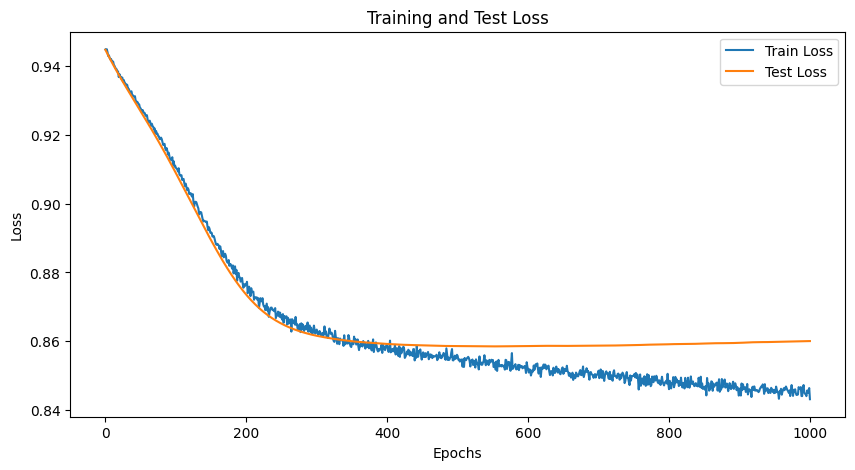

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.show()

Looking at the above plot, it can be seen that there is a c;assic case of overfitting as the test loss starts increasing around epoch 500 while the train loss continues decreasing.

For this reason, I will retrain the model but this time with 500 epochs.

In [29]:
""" Re-Running the train and test loop """

mlp = MLPModel(input_dim=37)
pos_weight = torch.tensor([2.125]) # This is the same we used for XGB
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(
    params=mlp.parameters(), lr=0.0001
)

epochs = 501
threshold = 0.0001

for i in range(epochs):

    mlp.train()
    train_pred = mlp(X_train_tensor).squeeze()
    loss = loss_fn(train_pred, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    mlp.eval()
    with torch.no_grad():
        test_pred = mlp(X_test_tensor).squeeze()
        loss_test = loss_fn(test_pred, y_test_tensor)

    if i % 100 == 0:
        print(f'Epoch: {i}, Train Loss: {loss.item()}, Test Loss: {loss_test.item()}')

    if loss.item() < threshold:
        print('Loss already below threshold\nBreaking...')
        break


Epoch: 0, Train Loss: 0.9402149319648743, Test Loss: 0.9391610622406006
Epoch: 100, Train Loss: 0.9065515995025635, Test Loss: 0.9043092131614685
Epoch: 200, Train Loss: 0.8727307915687561, Test Loss: 0.8714813590049744
Epoch: 300, Train Loss: 0.8638753890991211, Test Loss: 0.8619961738586426
Epoch: 400, Train Loss: 0.8613204956054688, Test Loss: 0.8596209287643433
Epoch: 500, Train Loss: 0.8567764759063721, Test Loss: 0.8589296340942383


## Models Evaluation and Comparison

In the following section I evaluate and compare both models based on their classification reports, roc-auc curve and precision-recall-f1 decision threshold to see if there's any difference between the two models.

In [39]:
xgb_pred = xgb.predict(X_test)
mlp_pred = (torch.sigmoid(mlp(X_test_tensor)) > 0.5).int().numpy().flatten()
xgb_pred_prob = xgb.predict_proba(X_test)[:, 1]
mlp_pred_prob = torch.sigmoid(mlp(X_test_tensor)).detach().numpy()

In [40]:
from sklearn.metrics import (
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

# ============================================
# Classification Reports
# ============================================

xgb_clf_report = classification_report(
    y_test,
    xgb_pred,
    output_dict=True
)

mlp_clf_report = classification_report(
    y_test,
    mlp_pred,
    output_dict=True
)


# ============================================
# ROC Curve Metrics
# ============================================

xgb_fpr, xgb_tpr, xgb_roc_thresholds = roc_curve(
    y_test,
    xgb_pred_prob
)

mlp_fpr, mlp_tpr, mlp_roc_thresholds = roc_curve(
    y_test,
    mlp_pred_prob
)

xgb_roc_auc = roc_auc_score(y_test, xgb_pred_prob)
mlp_roc_auc = roc_auc_score(y_test, mlp_pred_prob)


# ============================================
# Precision-Recall Metrics
# ============================================

xgb_precision, xgb_recall, xgb_pr_thresholds = precision_recall_curve(
    y_test,
    xgb_pred_prob
)

mlp_precision, mlp_recall, mlp_pr_thresholds = precision_recall_curve(
    y_test,
    mlp_pred_prob
)


# ============================================
# F1 Scores Across Thresholds
# ============================================

xgb_f1_scores = (
    2 * (xgb_precision[:-1] * xgb_recall[:-1]) /
    (xgb_precision[:-1] + xgb_recall[:-1] + 1e-10)
)

mlp_f1_scores = (
    2 * (mlp_precision[:-1] * mlp_recall[:-1]) /
    (mlp_precision[:-1] + mlp_recall[:-1] + 1e-10)
)


# ============================================
# Store Results
# ============================================

evaluation_results = {

    "xgboost": {

        "classification_report": xgb_clf_report,

        "roc_curve": {
            "fpr": xgb_fpr,
            "tpr": xgb_tpr,
            "thresholds": xgb_roc_thresholds,
            "auc": xgb_roc_auc
        },

        "precision_recall_f1": {
            "precision": xgb_precision[:-1],
            "recall": xgb_recall[:-1],
            "f1_scores": xgb_f1_scores,
            "thresholds": xgb_pr_thresholds
        }
    },

    "mlp": {

        "classification_report": mlp_clf_report,

        "roc_curve": {
            "fpr": mlp_fpr,
            "tpr": mlp_tpr,
            "thresholds": mlp_roc_thresholds,
            "auc": mlp_roc_auc
        },

        "precision_recall_f1": {
            "precision": mlp_precision[:-1],
            "recall": mlp_recall[:-1],
            "f1_scores": mlp_f1_scores,
            "thresholds": mlp_pr_thresholds
        }
    }
}

#### Classification Reports

Below I present and compare the classification reports for both models

In [44]:
print(f'XGBoost Classification Report:\n\n{pd.DataFrame(evaluation_results["xgboost"]["classification_report"]).T}')
print('\n\n')
print(f'MLP Classification Report:\n\n{pd.DataFrame(evaluation_results["mlp"]["classification_report"]).T}')

XGBoost Classification Report:

              precision    recall  f1-score      support
0              0.794892  0.672987  0.728878  3006.000000
1              0.470081  0.625538  0.536781  1394.000000
accuracy       0.657955  0.657955  0.657955     0.657955
macro avg      0.632486  0.649263  0.632829  4400.000000
weighted avg   0.691986  0.657955  0.668018  4400.000000



MLP Classification Report:

              precision    recall  f1-score      support
0              0.793469  0.646707  0.712610  3006.000000
1              0.455385  0.637016  0.531100  1394.000000
accuracy       0.643636  0.643636  0.643636     0.643636
macro avg      0.624427  0.641861  0.621855  4400.000000
weighted avg   0.686358  0.643636  0.655104  4400.000000


**Classification Report Comparison**

Overall, both models show very similar performance patterns, with no large separation in predictive quality. Differences are mostly marginal and consistent rather than structural.

On the majority class, XGBoost performs slightly better and appears a bit more stable in its balance between precision and recall. The MLP is close but slightly less consistent.

On the minority class, the MLP leans toward higher recall, while XGBoost maintains slightly better precision. This reflects a mild trade-off between capturing more positives versus reducing false positives.

Across macro and weighted averages, XGBoost maintains a small but consistent edge, suggesting slightly better overall balance across classes.

In summary, both models are comparable, with XGBoost showing marginally stronger overall stability, and the MLP showing a slight tendency toward higher sensitivity on the positive class.

---

Let's continue the comparison by plotting the ROC curves and vakues below.


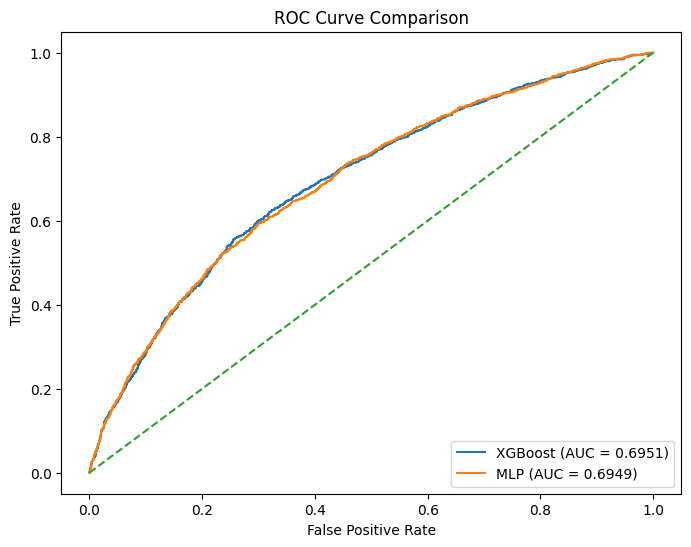

In [47]:
from sklearn.metrics import auc

plt.figure(figsize=(8, 6))

# XGBoost ROC
plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {xgb_roc_auc:.4f})"
)

# MLP ROC
plt.plot(
    mlp_fpr,
    mlp_tpr,
    label=f"MLP (AUC = {mlp_roc_auc:.4f})"
)

# Baseline (random classifier)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")

plt.show()

**ROC Curve Comparison**

The ROC curves for both models largely overlap across the entire range of thresholds, indicating very similar ranking performance. There is no clear region where one model consistently dominates the other in separating positive from negative classes.

This aligns with the close AUC values and suggests that both models have comparable discriminative ability. Any differences observed are minor and not structurally significant.

Overall, the ROC analysis reinforces the earlier findings: neither model shows a decisive advantage in terms of classification separability on this dataset.

---

Finally, we'll compare the precision-recall-curve to see if any curve has a higher decision threahold for detecting a higher number of frauds, i.e. higher recall without sacrificing too much precision, as this is the goal of fraud predictions.


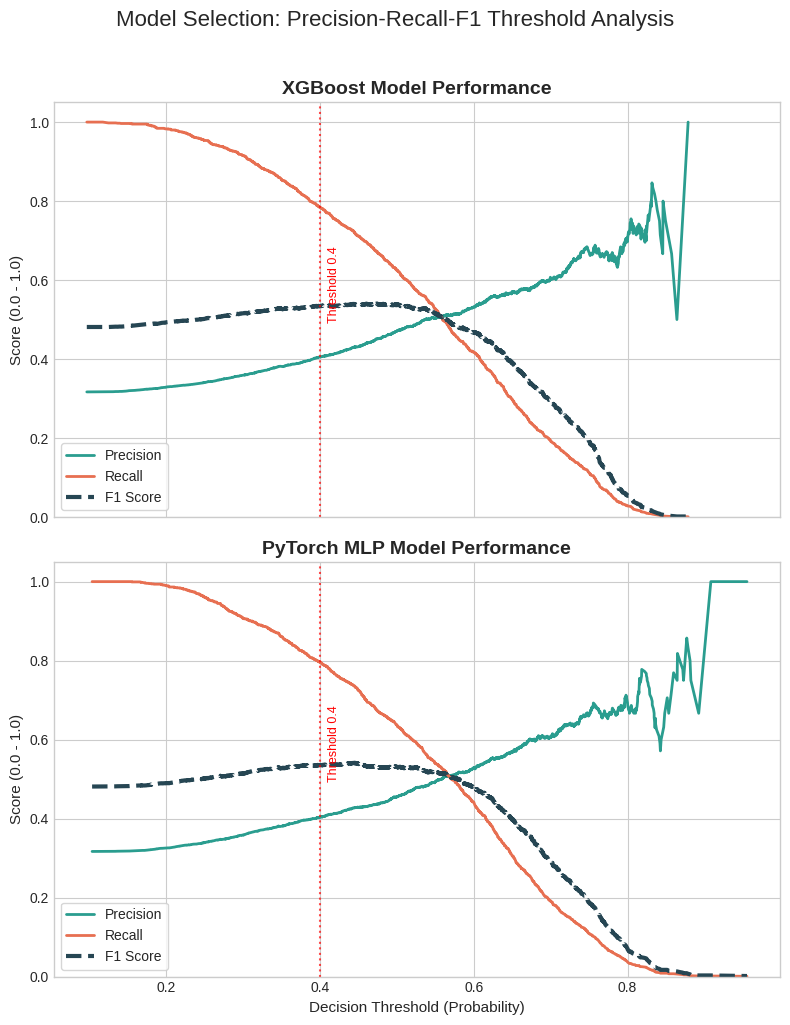

In [65]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

def style_plot(ax, precision, recall, f1, thresholds, model_name):
    ax.plot(thresholds, precision[:-1], label="Precision", color='#2A9D8F', linewidth=2)
    ax.plot(thresholds, recall[:-1], label="Recall", color='#E76F51', linewidth=2)
    ax.plot(thresholds, f1, label="F1 Score", color='#264653', linewidth=3, linestyle='--')

    ax.axvline(x=0.4, linestyle=':', c='red', alpha=0.7)
    ax.text(0.41, 0.5, 'Threshold 0.4', rotation=90, color='red', fontsize=9)

    ax.set_title(f"{model_name} Model Performance", fontsize=14, fontweight='bold')
    ax.set_ylabel("Score (0.0 - 1.0)", fontsize=11)
    ax.legend(loc='lower left', frameon=True)
    ax.set_ylim(0, 1.05)

style_plot(axes[0], xgb_precision, xgb_recall, xgb_f1_scores, xgb_pr_thresholds, "XGBoost")
style_plot(axes[1], mlp_precision, mlp_recall, mlp_f1_scores, mlp_pr_thresholds, "PyTorch MLP")

axes[1].set_xlabel("Decision Threshold (Probability)", fontsize=11)
fig.suptitle('Model Selection: Precision-Recall-F1 Threshold Analysis', fontsize=16, y=1.02)
plt.tight_layout()

plt.savefig('decision_threshold_curves.png', dpi=300, bbox_inches='tight')
plt.show()


**Threshold Analysis Interpretation**

Across the full decision threshold range, both models exhibit very similar precision–recall–F1 trade-offs. There is no meaningful separation in performance trajectories, which suggests that both models are learning largely the same signal structure from the data.

At the manually chosen reference threshold (0.4), neither model shows a decisive advantage. Their precision and recall profiles are closely aligned, and any differences in F1 are marginal and not stable enough to justify model preference based on a single operating point.

More importantly, the shape of both curves is similar:
- Precision and recall move in expected opposing directions
- F1 peaks occur in roughly comparable regions
- No model demonstrates a clearly dominant operating region across thresholds

---

As both models have performed closely similar based on evaluation metrics, now we look at a secondary metric and compare, `interpretability`.


In [68]:
importance = xgb.get_booster().get_score(importance_type='gain')

importance_df = pd.DataFrame(importance.items(), columns=['Feature', 'Importance'])
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

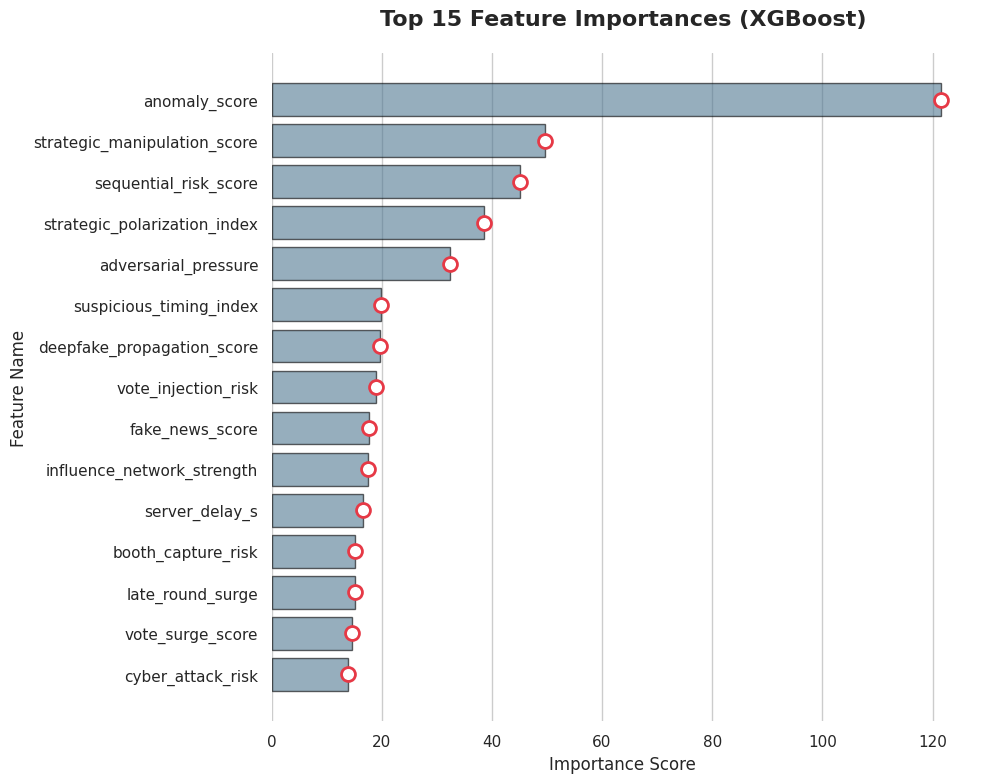

In [83]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

bar_color = '#457b9d'
line_color = '#e63946'

ax = sns.barplot(
    data=importance_df[:15],
    x='Importance',
    y='Feature',
    color=bar_color,
    edgecolor='black',
    alpha=0.6
)
sns.lineplot(
    data=importance_df[:15].sort_values('Importance', ascending=False),
    x='Importance',
    y='Feature',
    color=line_color,
    marker='o',
    markersize=10,
    linewidth=0,
    markerfacecolor='white',
    markeredgecolor=line_color,
    markeredgewidth=2
)

plt.title('Top 15 Feature Importances (XGBoost)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig('feature_importance_xgb.png', dpi=300, bbox_inches='tight')
plt.show()


**Feature Importance Interpretation (XGBoost)**

The model is strongly driven by a small set of high-signal variables, with one feature clearly dominating the decision structure: anomaly_score. This suggests that the model relies heavily on a consolidated indicator of irregular behavior, with most other variables playing supporting or corrective roles rather than primary decision drivers.

Beyond this dominant feature, importance is distributed across several conceptually related groups. A second tier of influential variables includes strategic and adversarial indicators (e.g., manipulation, polarization, and risk-related scores). This indicates that the model is primarily learning a structured notion of “system-level interference or abnormal activity” rather than isolated demographic or administrative signals.

A third tier consists of operational and contextual features such as timing dynamics, turnout-related variables, and network or infrastructure signals. These features contribute incremental refinement but are not primary determinants of prediction outcomes.

Overall, the structure is highly skewed: a few engineered composite risk features account for a disproportionate share of predictive power, while the remainder form a long tail of marginal contributors.

**Comparison with MLP Feature Importance**

Unlike XGBoost, the MLP does not provide native feature importance scores. This is because neural networks learn distributed representations across layers, rather than explicit split-based decision contributions per feature.
To extract feature importance from an MLP, one must use indirect methods such as:

- Permutation importance (most standard approach)
- SHAP values (more accurate but computationally expensive)
- Gradient-based attribution methods (e.g., Integrated Gradients)
- Weight-based heuristics (generally unreliable for interpretation)

The most practical approach in this case is permutation importance:
- shuffle one feature at a time
- measure drop in model performance
- rank features by performance degradation

This makes MLP interpretability significantly more computationally expensive and methodologically indirect compared to XGBoost.

**Conclusion**:

Even though predictive performance is similar, XGBoost provides a substantially stronger interpretability framework, which is critical in applied decision systems. The ability to directly inspect feature influence makes it more suitable for analytical and policy-oriented environments compared to the MLP, where interpretability is indirect and computationally expensive.

## Conclusion and Summary of Findings

This project set out to compare XGBoost and a PyTorch-based MLP on a structured classification task, evaluating both models across classification metrics, ROC and precision-recall behavior, threshold sensitivity, and feature importance analysis.

Across all evaluation dimensions, both models exhibit closely aligned performance. Differences in accuracy, F1-score, ROC-AUC, and precision-recall behavior are consistently marginal, with no model demonstrating a clear or robust advantage across all metrics. This suggests that, for the given dataset and feature engineering structure, both models converge toward similar decision boundaries and extract comparable predictive signal from the data.

The threshold analysis further reinforces this outcome, showing near-identical precision-recall-F1 trade-offs across decision thresholds. Neither model maintains a stable performance advantage across the operating range, and both exhibit similar optimal regions for classification performance.

Which model to select will therefore depend less on predictive performance, since both models achieve comparable results across all evaluation metrics, and more on secondary considerations that determine practical usability in real-world deployment contexts.

Key selection criteria include:

- **Hardware constraints:** XGBoost is generally more efficient on CPU-based environments and performs well under limited computational resources, whereas the MLP may require more computational overhead and benefits more from GPU acceleration.
- **Computational efficiency:** XGBoost typically trains faster, requires less hyperparameter tuning, and is more stable during training, while the MLP may require iterative tuning and longer convergence time depending on architecture.
- **Interpretability requirements:** If model transparency is a core objective, XGBoost is preferable due to its native feature importance measures and more explicit decision structure. The MLP, by contrast, is a black-box model requiring indirect post-hoc interpretability techniques.
- **Deployment and operational complexity**: XGBoost models are generally easier to serialize, deploy, and integrate into production systems with minimal infrastructure overhead. MLPs may require more complex serving pipelines, especially in GPU-dependent setups.
- **Scalability and extensibility**: The MLP framework may become more advantageous in scenarios involving very large datasets, unstructured data integration, or transfer learning requirements, where neural architectures offer greater flexibility.
- **Monitoring and maintainability**: Tree-based models like XGBoost are often easier to debug, monitor, and recalibrate in production environments due to their structured decision logic.

---


In summary, since predictive performance is effectively equivalent, model selection becomes a systems-level decision rather than a statistical one, driven by constraints of infrastructure, interpretability, and operational context rather than differences in accuracy or ranking ability.